In [32]:
# 이상감지라는 것은 사전감지로써, 설비가 파손되기 전 조치를 취할 수 있도록
# autuencoder는 분류/회귀 둘 다 아니고 딥러닝 모델이다.

# ============================================================
# 1. 라이브러리 호출
# ============================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import tensorflow as tf
from matplotlib.lines import lineStyles
from matplotlib.pyplot import autumn
from sklearn.model_selection import train_test_split
from tensorflow.keras import layers, models
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
 accuracy_score, precision_score, recall_score, f1_score, roc_auc_score,
confusion_matrix, classification_report, roc_curve, auc, precision_recall_curve
)
from torch.backends.mkl import verbose
from torch.nn import Threshold

np.random.seed(42)
tf.random.set_seed(42)

In [33]:
# ============================================================
# 2. 가상 센서 데이터 생성
# ============================================================

n_normal = 5000 # 정상 데이터 샘플 수
n_anomaly = 500 # 이상 데이터 샘플 수
n_features = 4 # 센서 개수

# 정상 데이터 : 평균 0, 표준편차 1인 정규분포 내에서 값을 샘플링하여 센서 데이터 생성
normal_data =np.random.normal(loc= 0.0, scale= 1.0, size=(n_normal, n_features))
# 이상데이터 : 평균을 크게 이동시키고, 분산을 키워서 비정상적인 패터의 센서 데이터 생성
anomaly_data =np.random.normal(loc= 3.0, scale= 1.5, size=(n_anomaly, n_features))

X = np.vstack([normal_data, anomaly_data])# 정상과 이상 데이터를 위아래로 이어 붙임
y = np.hstack([np.zeros(n_normal), np.ones(n_anomaly)])# 정상은 0, 이상은 1 로 레이블 벡터를 만듦

In [34]:
# ============================================================
# 3. 학습/테스트 데이터 분리
# ============================================================
# 전체 데이터에서 70%를 학습용으로 사용하고, 30% 테스트용으로 나누고 레이블 비율 유지

# 학습데이터 70%, 테스트 데이터 30% 나눔
X_train, X_test, y_train, y_test = train_test_split(
    X,y, test_size=0.3,
    stratify=y,
    random_state=42
)

# 이상 탐지 autoencoder 는 보통 정상 데이터로만 학습하므로 정상 샘플만 필터링
X_train_normal = X_train[y_train ==0] #학습 데이터 중 레이블이 0(정상)인 데이터만 필터링


In [35]:
# ============================================================
#  4. 데이터 스케일링 (표준화)
# ============================================================

#트리모델이 아니기 때문에 스케일링 필요
scaler = StandardScaler() # 평균 0, 분산 1로 맞추는 표준화 객체 생성
scaler.fit(X_train_normal) # 정상 학습 데이터로 표준화 기준을 학습

X_train_normal_scaled = scaler.transform(X_train_normal)  # 학슴용 정상 데이터를 표준화
X_test_scaled = scaler.transform(X_test)    # 전체( 정상, 이상) 를 표준화

In [36]:
# ============================================================
#  5. Autoencoder 모델 정의
# ============================================================
#  오토인코더의 모델 네트워크를 구성하는 부분.

input_dim = n_features # 입력 차원은 센서 개수와 동일하게 설정
encoding_dim = 2 #잠재공간 () 2차원으로 설정해서 압축을 진행.

# 입력 레이어 정의, 입력 크기는 센서 개수와 동일하게 설정
input_layer = layers.Input(shape=(input_dim,), name='input_layer')

# 인코더 부분 : 입력을 더 작은 차원으로 압축한느 레이어
encoded = layers.Dense(8, activation='relu', name = 'encoder_dense1')(input_layer) #8개의 뉴런으로 첫 번째 레이어를 만듦.
encoded = layers.Dense(encoding_dim, activation='relu', name = 'encoder_dense2')(encoded) # 2차원 잠재 표현으로 압축한다.

# 디코더 부분 : 압축된 표현을 다시 원래 차원으로 복원한느 레이어
decoded = layers.Dense(8, activation='relu', name = 'decoder_dense1')(encoded) # 8개의 뉴런으로 복원을 하는 중간 레이어를 만듬
decoded = layers.Dense(input_dim, activation='linear', name = 'decoder_output')(decoded) # 원래 입력 차원으로 복원하는 출력함

# 입력부터 출력까지 연결해준느 autoencoder 모델 구성
autoencoder = models.Model(inputs=input_layer, outputs=decoded, name='autoencoder_model')

# 모델 구조 출력해서 설계된 레이러르 확인할 수가 있음
autoencoder.summary()

Model: "autoencoder_model"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 4)              │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ encoder_dense1 (Dense)          │ (None, 8)              │            40 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ encoder_dense2 (Dense)          │ (None, 2)              │            18 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ decoder_dense1 (Dense)          │ (None, 8)              │            24 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ decoder_output (Dense)          │ (None, 4)              │            36 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 118 (472.00 B)

 Trainable params: 118 (472.00 B)

 Non-trainable params: 0 (0.00 B)

# auto encoder의 학습 목표는?
입력과 출력으로 복원되는 것의 값의 차이가 나면 안됨. -> 복원오차를 MSE로 차이가 얼마나 나는지 보고, 차이를 줄이는 노력을 함.
- 정상에 대한 기준 세우는 것.

In [37]:
# ============================================================
#  6. Autoencoder 컴파일
# ============================================================

autoencoder.compile(
    optimizer='adam', #최적화 알고리즘 adam 사용
    loss = 'mse' #입력과 복원된 출력의 차이를 제곱오차 (MSE)로 계산
)

In [38]:
# ============================================================
#  7. Autoencoder 학습
# ============================================================

# 정상 데이터만 사용해서 학습을 시킨다.
history = autoencoder.fit(
    X_train_normal_scaled, #입력과 타겟이 동일한 정상 데이터를 사용
    X_train_normal_scaled, # 입력을 그대로 복원(decode) 하도록 학습
    epochs=70, # 70반복 학습
    batch_size=64,
    validation_split=0.2,
    verbose=1 # 학습진행상황을 로그로 출력
)

Epoch 1/70
44/44 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - loss: 0.9869 - val_loss: 0.9439
Epoch 2/70
44/44 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.9323 - val_loss: 0.8897
Epoch 3/70
44/44 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.8908 - val_loss: 0.8519
Epoch 4/70
44/44 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.8648 - val_loss: 0.8325
Epoch 5/70
44/44 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.8506 - val_loss: 0.8212
Epoch 6/70
44/44 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.8408 - val_loss: 0.8127
Epoch 7/70
44/44 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.8330 - val_loss: 0.8056
Epoch 8/70
44/44 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.8264 - val_loss: 0.7993
Epoch 9/70
44/44 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.8205 - val_loss: 0.7936
Epoch 10/70
44/44 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.8153 - val_loss: 0.7887
Epoch 11/70
44/44 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.8107 - val_loss: 0.7842
Epoch 12/70
44/44 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.8066 - val_lo

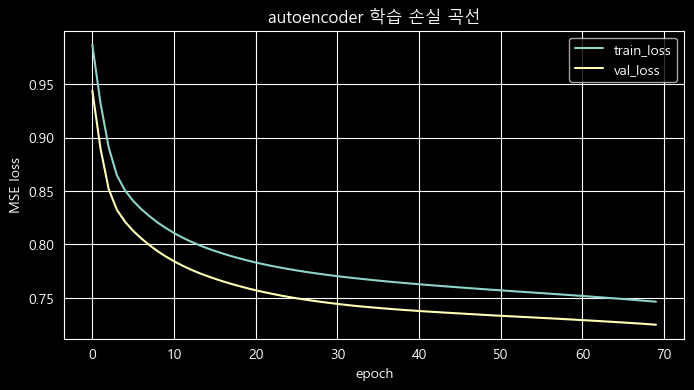

In [39]:
# ============================================================
#  8. 학습 과정 시각화 (loss)
# ============================================================

# 그래프 한글 폰트 설정
from matplotlib import  font_manager, rc
plt.rcParams['font.family'] = 'Malgun Gothic'
plt.rcParams['axes.unicode_minus'] = False

plt.figure(figsize=(8,4))
plt.plot(history.history['loss'],label = 'train_loss' )
plt.plot(history.history['val_loss'],label = 'val_loss')
plt.title('autoencoder 학습 손실 곡선')
plt.xlabel('epoch')
plt.ylabel('MSE loss')
plt.legend()
plt.grid(True)
plt.show()

In [43]:
# ============================================================
#  9. 테스트 데이터에서 재구성 오차 계산
# ============================================================

X_test_pred = autoencoder.predict(X_test_scaled) # 테스트 데이터를 autoencoder에 통과시켜서 목복원값을 얻어옴
reconstruction_error = np.mean(np.square(X_test_scaled - X_test_pred), axis=1)
# 각 샘플에 대해 (입력- 복원값)^2 을 계산하고, 특정 차원 방향으로 평균을 내서 재구성 오차를 구하는 결과..

52/52 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step


In [44]:
# ============================================================
#  10. 이상 탐지 임계값(threshold) 설정
# ============================================================

# 정상 학습 데이터의 재구성 오차 분포를 기반으로 임계값을 설정
X_train_pred = autoencoder.predict(X_train_normal_scaled)
train_reconstrucion_error = np.mean(
    np.square(X_train_normal_scaled - X_train_pred), axis = 1
)

threshold = np.percentile(train_reconstrucion_error, 95) # 정상 오차의 95%
print('이상 탐지 임계값 (95%) : ',threshold) #결정된 임계값 출력 확인

110/110 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step
이상 탐지 임계값 (95%) :  1.9003550346867502


재구성 오차 기반 ROC-AUC :  0.9962266666666666


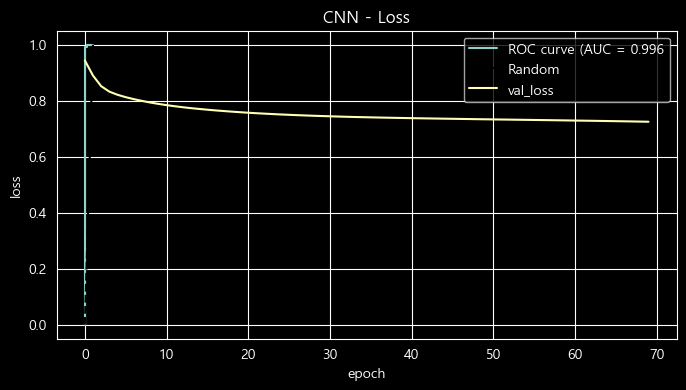

In [45]:
# ============================================================
#  11. 이상 여부 예측 및 ROC-AUC 평가
# ============================================================

# 재구성 오차가 임계값보다 크면 이상(1), 작으면 정상(0)으로 예측 레이블을 만듦
y_pred_anomaly = (reconstruction_error > threshold).astype(int)

# 재구성 오차를 점수로 사용해서 ROC_AUC 를 계산해서 이상탐지 성능 측정
auc = roc_auc_score(y_test, reconstruction_error)
print('재구성 오차 기반 ROC-AUC : ',auc) # 계산된 AUC 값을 출력

fpr, tpr , _ = roc_curve(y_test, reconstruction_error)  # ROC 곡선을 그리기 위해 FPR, tpr값을 계산

plt.figure(figsize=(8,4))
plt.plot(fpr, tpr, label = f'ROC curve (AUC = {auc:.3f}')
plt.plot([0, 1], [0, 1], 'k--', label = 'Random')
plt.plot(history.history['val_loss'],label = 'val_loss')
plt.title('CNN - Loss')
plt.xlabel('epoch')
plt.ylabel('loss')
plt.legend()
plt.grid(True)
plt.show()

제공해주신 코드를 보니 그래프가 이상하게 나오거나 "선이 안 보이는" 이유는 서로 성격이 완전히 다른 두 종류의 데이터를 하나의 그래프에 억지로 그려넣었기 때문일 가능성이 매우 높습니다.

현재 코드의 plt 부분에서 두 가지 상충되는 데이터가 섞여 있습니다:

1. ROC 커브: x축이 FPR(0~1), y축이 TPR(0~1)인 성능 지표 그래프.

2. Loss 커브: x축이 Epoch(학습 횟수), y축이 오차(Loss) 값인 학습 과정 그래프.

이 둘을 한 칸에 그리면 스케일이 맞지 않아 선이 겹치거나, 축 범위가 뒤틀려 그래프가 제대로 보이지 않게 됩니다.

🛠️ 문제 해결 방법: 그래프 분리하기
가장 깔끔한 방법은 **성능 평가(ROC)**와 **학습 경과(Loss)**를 각각 다른 그래프로 그리는 것입니다. 코드를 다음과 같이 수정해 보세요.

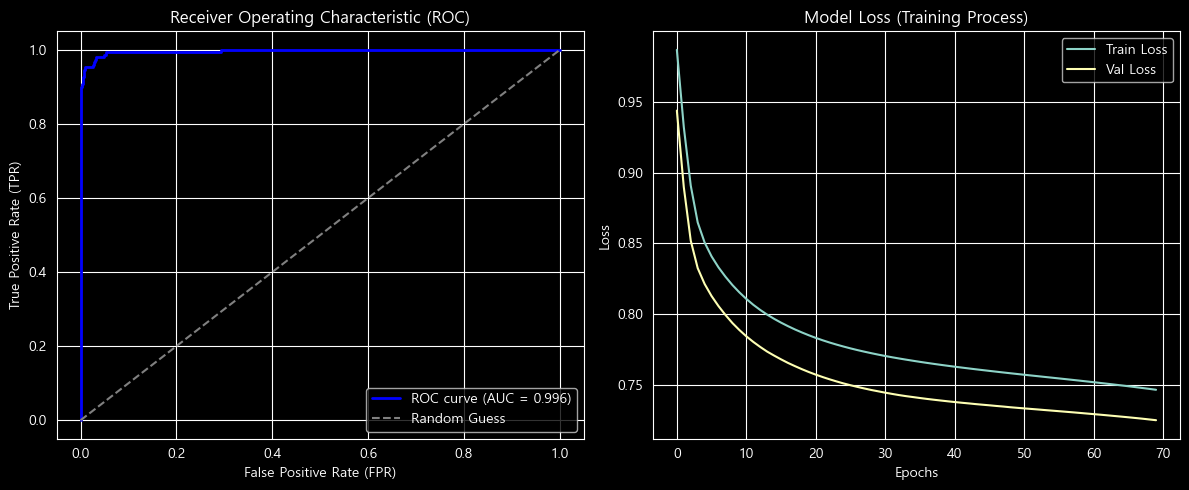

In [52]:
import matplotlib.pyplot as plt

# 1. ROC 커브 시각화 (모델의 이상탐지 성능 확인)
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1) # 1행 2열 중 첫 번째
plt.plot(fpr, tpr, color='blue', lw=2, label=f'ROC curve (AUC = {auc:.3f})')
plt.plot([0, 1], [0, 1], color='gray', linestyle='--', label='Random Guess')
plt.title('Receiver Operating Characteristic (ROC)')
plt.xlabel('False Positive Rate (FPR)')
plt.ylabel('True Positive Rate (TPR)')
plt.legend()
plt.grid(True)

# 2. 학습 손실 그래프 (모델이 공부를 잘 했는지 확인)
plt.subplot(1, 2, 2) # 1행 2열 중 두 번째
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Val Loss')
plt.title('Model Loss (Training Process)')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

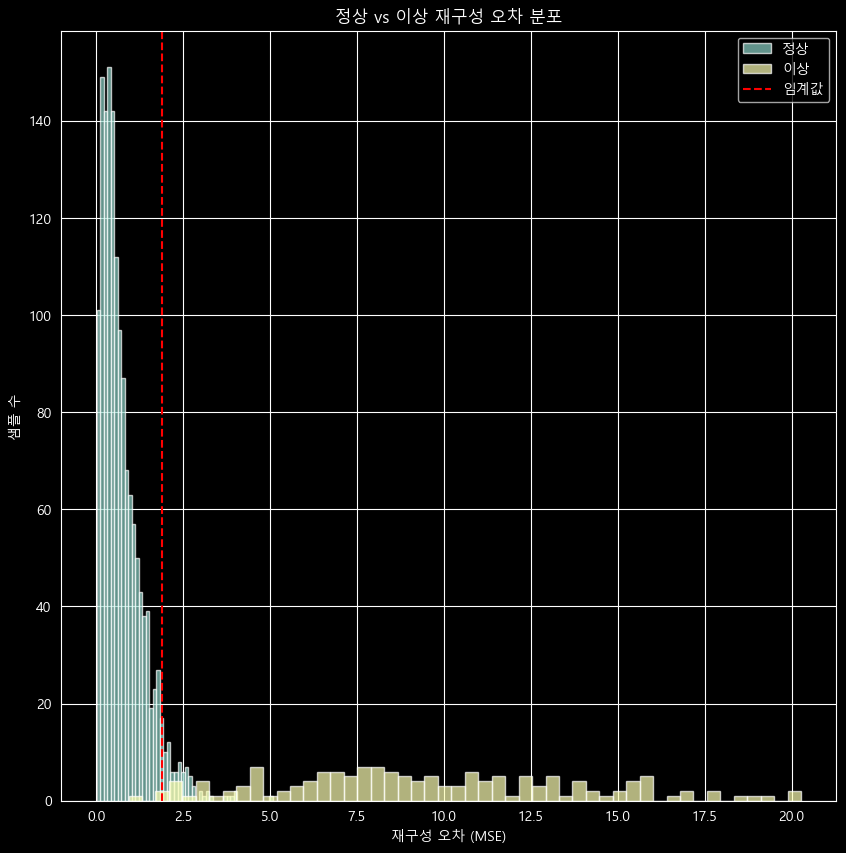

In [49]:
# ============================================================
#  12. 재구성 오차 분포 시각화
# ============================================================

# 학습 손실 그래프
plt.figure(figsize=(10,10))
plt.hist(reconstruction_error[y_test==0],bins= 50, alpha= 0.7, label = '정상')
plt.hist(reconstruction_error[y_test==1],bins= 50, alpha= 0.7, label = '이상')
plt.axvline(threshold, color = 'red', linestyle ="--", label = '임계값')
plt.title('정상 vs 이상 재구성 오차 분포')
plt.xlabel('재구성 오차 (MSE)')
plt.ylabel('샘플 수')
plt.legend()
plt.grid(True)
plt.show()